# Gemini Function Calling

Function Calling은 모델이 사용자의 요청을 해결하는 데 필요한 **외부 함수(도구)를 선택하고, 함수 이름과 인자를 구조화된 형태로 알려 주는 기능**입니다. 애플리케이션은 이 요청에 따라 Python 함수를 실행하고, 실행 결과를 다시 모델에 전달합니다. 모델은 그 결과를 바탕으로 사용자에게 보여 줄 최종 답변을 만듭니다.


공식 문서: https://ai.google.dev/gemini-api/docs/function-calling

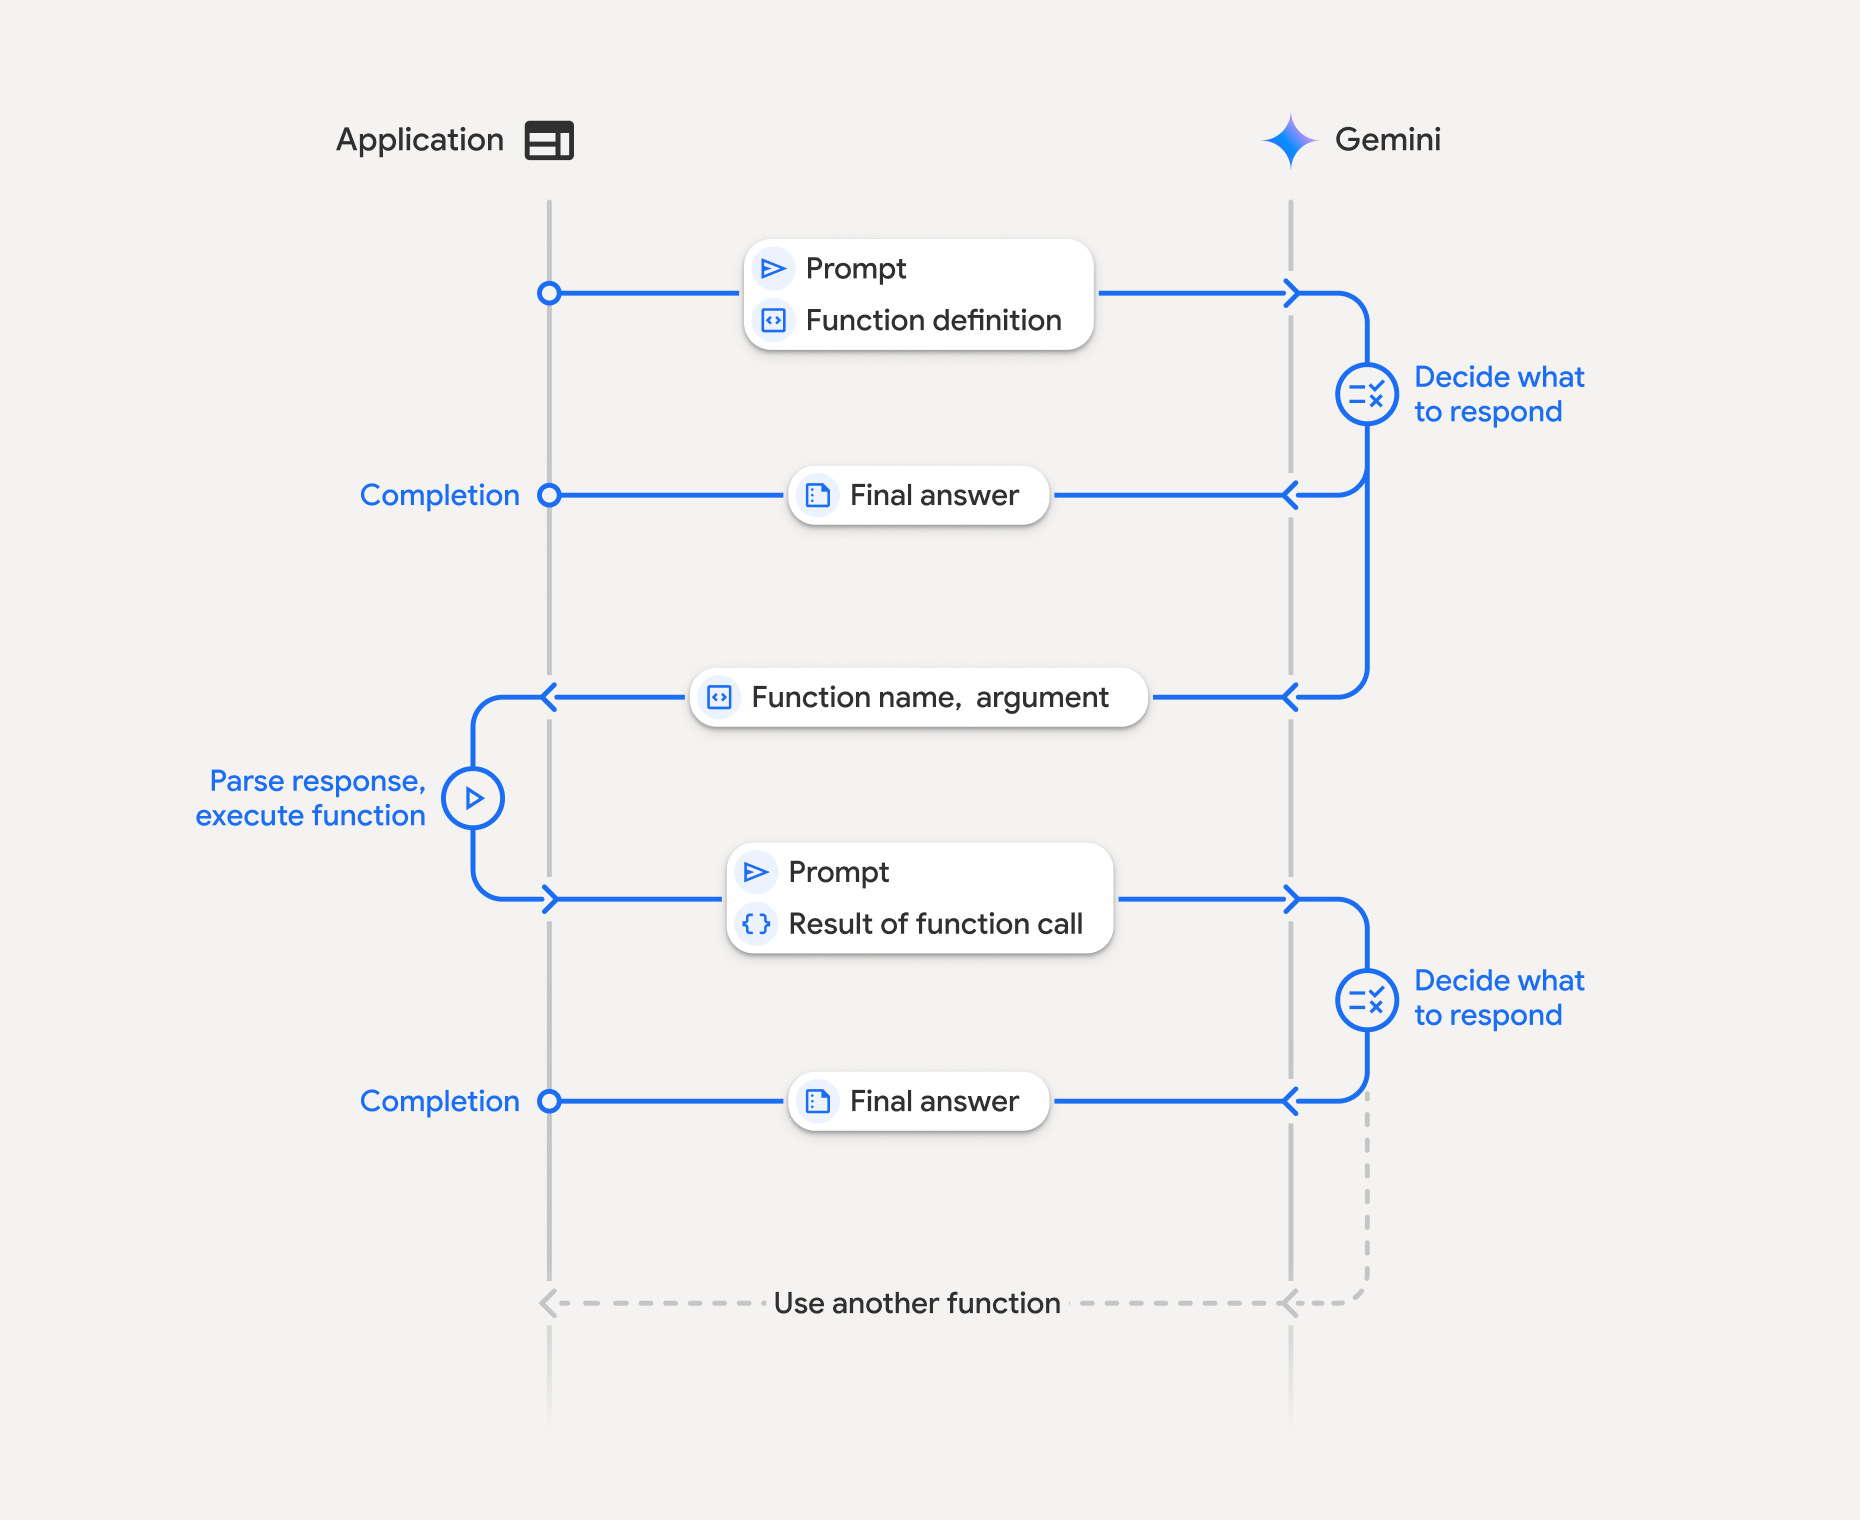

### 실습 환경 준비

In [1]:
import json
import os
from pprint import pprint

from dotenv import load_dotenv
from google import genai

load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
if not api_key:
    raise ValueError(".env 파일에 GEMINI_API_KEY를 설정해 주세요.")

model = os.getenv("GEMINI_MODEL", "gemini-3.6-flash")
client = genai.Client(api_key=api_key)
print("준비 완료 / 사용 모델:", model)

준비 완료 / 사용 모델: gemini-3.6-flash


### 모델이 사용할 Python 함수 만들기

실제 쇼핑몰 API 대신 메모리에 저장된 상품 데이터를 사용합니다. 모델은 이 함수를 볼 수도, 직접 실행할 수도 없습니다. 실행 권한은 항상 애플리케이션에 있습니다.

In [2]:
PRODUCTS = {
    "A100": {"name": "무선 키보드", "price": 39000, "stock": 12},
    "B200": {"name": "무선 마우스", "price": 25000, "stock": 0},
    "C300": {"name": "노트북 거치대", "price": 32000, "stock": 7},
}

def get_product(product_id: str) -> dict:
    """상품 ID로 상품 정보와 재고를 조회합니다."""

    product = PRODUCTS.get(product_id.upper())
    if product is None:
        return {"ok": False, "error": "상품을 찾을 수 없습니다."}
    
    return {"ok": True, "product_id": product_id.upper(), **product}

pprint(get_product("A100"))

{'name': '무선 키보드',
 'ok': True,
 'price': 39000,
 'product_id': 'A100',
 'stock': 12}


### 도구 schema 정의하기

도구 schema는 모델에게 함수의 사용법을 알려주는 설명서입니다.

- `name`: 모델이 반환할 도구 이름
- `description`: 언제 이 도구를 사용해야 하는지 설명
- `parameters`: JSON Schema 형식의 인자 정의
- `required`: 반드시 필요한 인자

설명이 모호하면 모델이 잘못된 도구를 선택하거나 잘못된 인자를 만들 수 있습니다.

In [3]:
get_product_tool = {
    "type": "function",
    "name": "get_product",
    "description": "상품 ID를 이용해 상품명, 가격, 현재 재고를 조회합니다.",
    "parameters": {
        "type": "object",
        "properties": {
            "product_id": {
                "type": "string",
                "description": "조회할 상품 ID. 예: A100",
            }
        },
        "required": ["product_id"],
    },
}

pprint(get_product_tool)

{'description': '상품 ID를 이용해 상품명, 가격, 현재 재고를 조회합니다.',
 'name': 'get_product',
 'parameters': {'properties': {'product_id': {'description': '조회할 상품 ID. 예: '
                                                             'A100',
                                              'type': 'string'}},
                'required': ['product_id'],
                'type': 'object'},
 'type': 'function'}


### 모델에게 도구 선택 맡기기

`tools`에 schema를 전달하면 모델은 질문에 도구가 필요하다고 판단할 때 `function_call` Step을 반환합니다. 이 시점에는 아직 Python 함수가 실행되지 않았습니다.

In [4]:
question = "A100 상품의 이름, 가격과 재고를 알려줘."

interaction = client.interactions.create(
    model=model,
    input=question,
    # 위에서 작성한 scheme를 전달합니다.
    tools=[get_product_tool],
    store=True,
)

function_call = None

for step in interaction.steps:
    print("step type:", step.type)
    # 모델이 반환한 Step 중 첫 번째 function_call을 저장합니다.
    if step.type == "function_call":
        function_call = step
        print("도구 이름:", step.name)
        print("호출 ID:", step.id)
        print("인자:", step.arguments)
        break

step type: thought
step type: function_call
도구 이름: get_product
호출 ID: call_153886
인자: {'product_id': 'A100'}


### 도구를 실행하고 결과 돌려주기

모델이 요청한 도구를 실행할 수 있도록, 사용할 Python 함수를 `TOOL_FUNCTIONS` 딕셔너리에 미리 등록합니다. 모델이 보낸 도구 이름으로 이 딕셔너리에서 함수를 찾아 실행하면 등록된 함수만 안전하게 사용할 수 있습니다.

또한 `function_result`의 `call_id`는 모델이 보낸 function call의 `id`와 같아야 합니다.

In [10]:
TOOL_FUNCTIONS = {
    "get_product": get_product,
}


if function_call is None:
    print("모델이 도구를 호출하지 않았습니다:", interaction.output_text)
elif function_call.name not in TOOL_FUNCTIONS:
    raise ValueError(f"허용되지 않은 도구입니다: {function_call.name}")

# 우리가 전달할 함수가 실행되는 경우.
else:
    tool_result = TOOL_FUNCTIONS[function_call.name](**function_call.arguments)
    pprint(tool_result)


{'name': '무선 키보드',
 'ok': True,
 'price': 39000,
 'product_id': 'A100',
 'stock': 12}


In [11]:
if function_call is not None:
    function_result = {
        "type": "function_result",
        "name": function_call.name,
        "call_id": function_call.id,
        "result": [{"type": "text", "text": json.dumps(tool_result, ensure_ascii=False)}],
    }

    final_interaction = client.interactions.create(
        model=model,
        input=[function_result],
        tools=[get_product_tool],
        previous_interaction_id=interaction.id,
        store=True,
    )
    print(final_interaction.output_text)

A100 상품의 정보는 다음과 같습니다.

* **상품명:** 무선 키보드
* **가격:** 39,000원
* **현재 재고:** 12개


### 왜 도구 결과를 다시 모델에 보내는가?

Python 함수의 반환값은 사용자에게 보여 줄 최종 문장이 아닐 수 있습니다. 모델은 도구 결과를 읽고 원래 질문에 맞는 자연스러운 답변을 작성합니다.

`store=True`는 Interaction 상태를 서버에 저장합니다. 함수 실행 결과를 보낼 때 `previous_interaction_id=interaction.id`를 함께 전달하면 서버가 해당 함수 호출과 결과를 연결합니다. Python 함수는 로컬 애플리케이션에서 실행됩니다.

### 여러 도구 등록하기

상품명으로 검색하는 도구를 하나 더 추가합니다. 각 도구의 역할이 겹치지 않도록 설명을 구체적으로 작성합니다. 두 도구를 `TOOLS`에 함께 넣어 모델에 전달하면 모델이 질문에 맞는 도구를 선택합니다.

In [14]:
def search_products(keyword: str) -> dict:
    """상품명에 keyword가 포함된 상품을 검색합니다."""
    keyword = keyword.strip().lower()
    if not keyword:
        return {"ok": False, "error": "검색어가 비어 있습니다."}

    # 상단의 PRODUCTS라는 딕셔너리에서
    # name에 keyword가 포함되어있는 item들을 모아두기.
    matches = [
        {"product_id": product_id, **product}
        for product_id, product in PRODUCTS.items()
        if keyword in product["name"].lower()
    ]
    return {"ok": True, "count": len(matches), "products": matches}

search_products_tool = {
    "type": "function",
    "name": "search_products",
    "description": "상품 ID를 모를 때 상품명에 포함된 검색어로 상품 목록을 찾습니다.",
    "parameters": {
        "type": "object",
        "properties": {
            "keyword": {"type": "string", "description": "상품명 검색어"}
        },
        "required": ["keyword"],
    },
}


TOOLS = [search_products_tool, get_product_tool]
TOOL_FUNCTIONS["search_products"] = search_products

print(search_products('마우스'))
print(TOOL_FUNCTIONS["search_products"]('마우스'))


{'ok': True, 'count': 1, 'products': [{'product_id': 'B200', 'name': '무선 마우스', 'price': 25000, 'stock': 0}]}
{'ok': True, 'count': 1, 'products': [{'product_id': 'B200', 'name': '무선 마우스', 'price': 25000, 'stock': 0}]}


In [15]:
multi_tool_interaction = client.interactions.create(
    model=model,
    input="무선 상품을 찾아줘.",
    tools=TOOLS,
    store=False,
)

for step in multi_tool_interaction.steps:
    if step.type == "function_call":
        print("모델이 선택한 도구:", step.name)
        print("모델이 만든 인자:", step.arguments)

        tool_function = TOOL_FUNCTIONS[step.name]
        tool_result = tool_function(**step.arguments)
        print("도구 실행 결과:")
        pprint(tool_result)

모델이 선택한 도구: search_products
모델이 만든 인자: {'keyword': '무선'}
도구 실행 결과:
{'count': 2,
 'ok': True,
 'products': [{'name': '무선 키보드',
               'price': 39000,
               'product_id': 'A100',
               'stock': 12},
              {'name': '무선 마우스',
               'price': 25000,
               'product_id': 'B200',
               'stock': 0}]}


### 반복 가능한 Agent loop 만들기

한 번의 질문에 도구 호출이 여러 단계 필요할 수 있습니다. 예를 들어 사용자가 상품 ID를 모르면 먼저 상품을 검색하고, 그 결과의 ID로 재고를 조회해야 합니다.

loop에는 반드시 최대 반복 횟수를 둡니다. 그렇지 않으면 모델이 계속 도구를 호출할 때 비용과 시간이 무한히 증가할 수 있습니다.

In [16]:
def execute_tool_call(step) -> dict:
    tool_function = TOOL_FUNCTIONS.get(step.name)
    if tool_function is None:
        return {"ok": False, "error": f"허용되지 않은 도구: {step.name}"}

    try:
        return tool_function(**step.arguments)
    except TypeError as error:
        return {"ok": False, "error": f"잘못된 인자: {error}"}
    except Exception as error:
        return {"ok": False, "error": f"도구 실행 실패: {type(error).__name__}"}

def run_agent(user_input: str, max_turns: int = 5) -> dict:
    next_input = user_input
    previous_interaction_id = None
    logs = []

    for turn in range(1, max_turns + 1):
        request = {
            "model": model,
            "input": next_input,
            "tools": TOOLS,
            "system_instruction": (
                "상품 상담원입니다. 추측하지 말고 필요한 상품 정보는 도구로 확인하세요. "
                "도구 결과에 없는 정보는 없다고 말하세요."
            ),
            "store": True,
        }
        if previous_interaction_id is not None:
            request["previous_interaction_id"] = previous_interaction_id

        interaction = client.interactions.create(**request)
        function_calls = [step for step in interaction.steps if step.type == "function_call"]

        if not function_calls:
            return {
                "ok": True,
                "answer": interaction.output_text,
                "turns": turn,
                "tool_logs": logs,
            }

        next_input = []
        for step in function_calls:
            result = execute_tool_call(step)
            logs.append({"turn": turn, "tool": step.name, "arguments": step.arguments, "result": result})
            next_input.append({
                "type": "function_result",
                "name": step.name,
                "call_id": step.id,
                "result": [{"type": "text", "text": json.dumps(result, ensure_ascii=False)}],
            })

        previous_interaction_id = interaction.id

    return {
        "ok": False,
        "answer": None,
        "turns": max_turns,
        "tool_logs": logs,
        "error": "최대 반복 횟수를 초과했습니다.",
    }

In [17]:
result = run_agent("무선 마우스를 사고 싶은데 가격과 재고를 확인해줘.")
print(result["answer"] if result["ok"] else result["error"])
print("\n도구 실행 기록")
pprint(result["tool_logs"])

조회하신 무선 마우스(상품 ID: B200)의 정보는 다음과 같습니다.

- **상품명**: 무선 마우스
- **가격**: 25,000원
- **현재 재고**: 0개 (재고 없음)

도구 실행 기록
[{'arguments': {'keyword': '무선 마우스'},
  'result': {'count': 1,
             'ok': True,
             'products': [{'name': '무선 마우스',
                           'price': 25000,
                           'product_id': 'B200',
                           'stock': 0}]},
  'tool': 'search_products',
  'turn': 1},
 {'arguments': {'product_id': 'B200'},
  'result': {'name': '무선 마우스',
             'ok': True,
             'price': 25000,
             'product_id': 'B200',
             'stock': 0},
  'tool': 'get_product',
  'turn': 2}]


### 전체 흐름 요약

Function Calling에서는 모델과 애플리케이션이 다음 순서로 역할을 나눕니다.

`사용자 질문` → `모델의 function_call` → `애플리케이션의 Python 함수 실행` → `function_result 전달` → `모델의 최종 답변`

모델은 어떤 도구를 어떤 인자로 호출할지 결정하고, 애플리케이션은 등록된 Python 함수를 실행합니다. 함수 결과를 다시 받은 모델은 그 내용을 사용자가 이해하기 쉬운 답변으로 정리합니다.

### 실습 문제 1: 배송비 계산 도구

다음 요구사항을 만족하는 `get_shipping_fee` 도구를 만드세요.

- `region`과 `order_amount`를 인자로 받습니다.
- 주문 금액이 50,000원 이상이면 배송비는 0원입니다.
- 그보다 작으면 기본 배송비는 3,000원입니다.
- 제주 지역은 기본 배송비에 3,000원을 추가합니다.
- 음수 주문 금액은 오류로 반환합니다.
- Python 함수, 도구 schema, 도구 등록과 실행 코드를 모두 작성합니다.

In [ ]:
# 1. 함수를 만든다.
# 2. 함수에 대한 설명을 작성한다.
# 3. llm에 요청을 보낼 때 그것을 같이 전달한다.
# 4.a llm이 일반 답변을 준다 -> 그냥 사용한다.
# 4.b llm이 함수를 실행하라고 알려준다 
#   -> 함수를 실행하고 결과값을 다시 llm에게 전달한다.
#   -> 4번 반복

In [30]:
# 1. 함수를 만든다.
# - `region`과 `order_amount`를 인자로 받습니다.
def get_shipping_fee(region: str, order_amount: int) -> int:
    """배송지와 주문 금액을 바탕으로 배송비를 계산해줍니다."""
# - 주문 금액이 50,000원 이상이면 배송비는 0원입니다.
    fee = 0
    if order_amount >= 50000:
        fee = 0
    elif order_amount >=0:
        fee = 3000
    else:
        raise Exception('음수 주문 금액')

    if region == '제주':
        fee += 3000
    return fee


# 2. 함수에 대한 설명을 작성한다. - scheme

get_shipping_fee_tool = {
    "type": "function",
    "name": "get_shipping_fee",
    "description": "배송지와 주문 금액을 바탕으로 배송비를 계산해줍니다.",
    "parameters": {
        "type": "object",
        "properties": {
            "region": {
                "type": "string",
                "description": "배송지",
            },
            "order_amount": {
                "type": "integer",
                "description": "주문 금액",
            },
        },
        "required": ["region", "order_amount"],
    },
}

TOOL_FUNCTION_MAPPING = {
    "get_shipping_fee" : get_shipping_fee
}

# 3. llm에 요청을 보낼 때 그것을 같이 전달한다.
interaction = client.interactions.create(
    model=model,
    input="서울로 5000원 구매해서 배송하면 배송비가 얼마지?",
    # 위에서 작성한 scheme를 전달합니다.
    tools=[get_shipping_fee_tool],
    store=True,
)

# 응답 => 함수 실행해서 결과 얻기
for step in interaction.steps:
    print(step)
    if step.type == 'function_call':
        tool_result = TOOL_FUNCTION_MAPPING[step.name](**step.arguments)
        print(tool_result)
    
        function_result = {
            "type": "function_result",
            "name": step.name,
            "call_id": step.id,
            "result": [{
                "type": "text", 
                "text": json.dumps(tool_result, ensure_ascii=False)}],
        }

# llm에게 함수의 결과 전달하기.
interaction = client.interactions.create(
    model=model,
    input=[function_result],
    # 위에서 작성한 scheme를 전달합니다.
    tools=[get_shipping_fee_tool],
    previous_interaction_id=interaction.id,
    store=True,
)

print(interaction.output_text)

# 4.a llm이 일반 답변을 준다 -> 그냥 사용한다.
# 4.b llm이 함수를 실행하라고 알려준다 
#   -> 함수를 실행하고 결과값을 다시 llm에게 전달한다.
#   -> 4번 반복

signature='EqUDCqIDARFNMg/6HezD8fEzhYJZMTxc6d2QcC5HNSvX/4qKqI5UeTdvPY+pILRU+VLThwGTYnY7MHSAPfaQXw+AqJRGJd+uAWwk8q5LfwupaNY3dOpTj5xN9Wmqem2OM0Y1pZ3PpcncK6NFEhSGYq3QpDC4tb4ahjfg49ngKMhpZat9Oq/p58/80uObytFzbsjHrlVVnjPBEXivVDMW+kim7ZzPEcT5jtzejGJ6TIw8QX0HEpKo9U96KO4b+5y0KZw5wkZCbhXWAMKpMRi/MKZ1B517rTe4K0tatipeGKV1E1tgGH1qjyFjGSSyDeocZhEaPYq75Lx4QTeIom1oU9YjWeZCVfP+jKkMiZWtz0c+I6r82QlIq2Uv/VjTjjDmm79a2Yp8BJ+YC2Tc8XXTBZWn/lmV47mpVMiknpxTEa+bds0cVUcxMUe37PzKL3h22k/LqkCePUJqc1Mh+uFlxHJt6HpgHRB6WHlYvaGvfR57e1WK0YBv/PEQOE2n2IhZ99Wq39Nh9DRilFNvE8pA1LjDSvwO5sMAwLuIlMrH+lHJ/dMWIf4g+A==' summary=None type='thought'
arguments={'region': '서울', 'order_amount': 5000} id='call_296377' name='get_shipping_fee' type='function_call'
3000
서울 지역으로 5,000원 구매 시 배송비는 **3,000원**입니다.


In [49]:
# 위의 과정을 함수로 만들어보자.

TOOL_FUNCTION_MAPPING = {
    "get_shipping_fee" : get_shipping_fee
}
tools = [get_shipping_fee_tool]

def llm_invoke(user_input: str, tools: list[dict], tool_function_mapping):
    max_attemp = 5
    next_input = user_input
    previous_interaction_id = None
    for _ in range(max_attemp):
        # 첫번째 요청
        # 두번째 이상의 요청과의 차이점 : input. previous_interaction_id

        args = {
            "model" : model,
            "input" : next_input,
            # 위에서 작성한 scheme를 전달합니다.
            "tools" : tools,
            # "previous_interaction_id"  :  previous_interaction_id,
            "store" : True,
        }

        # None일 때 아예 args에 들어가지 않도록 합니다.
        if previous_interaction_id is not None:
            args['previous_interaction_id'] = interaction.id

        interaction = client.interactions.create(**args)

        # 이 아래에서
        # next_input을 바꿀꺼야.
        # previous_interaction_id를 바꿀꺼야.
        # if function_call이 없어:
        # model_oupput return해

        function_calls = [step  
                        for step in interaction.steps 
                        if step.type == 'function_call'
                        ]
        
        if not function_calls:
            return interaction.output_text
        
        # function_call이 존재함 -> not function_calls가 False이기 때문에.
        next_input = []
        for function_call in function_calls:
            tool_result = tool_function_mapping[function_call.name](**function_call.arguments)

            print(function_call.name)

            function_result = {
                "type": "function_result",
                "name": function_call.name,
                "call_id": function_call.id,
                "result": [{
                    "type": "text", 
                    "text": json.dumps(tool_result, ensure_ascii=False)}],
            }

            next_input.append(function_result)

        previous_interaction_id = interaction.id


result = llm_invoke("서울로 5000원 구매해서 배송하면 배송비가 얼마지?", tools=tools, tool_function_mapping=TOOL_FUNCTION_MAPPING)

print(result)

for _ in range(5):
    user_input = input()
    result = llm_invoke(user_input, tools=tools, tool_function_mapping=TOOL_FUNCTION_MAPPING)

    # 챗봇이 완성.
    # 문제점 : 요청마다 이전 요청을 기억 못할거에요.
    # 그럼 어떻게 하면 될까요?

get_shipping_fee


KeyboardInterrupt: 

### 실습 문제 2: 쿠폰 할인 도구

다음 요구사항을 만족하는 `get_coupon_discount` 도구를 만드세요.

- `coupon_code`를 인자로 받습니다.
- `WELCOME10`은 할인율 10%, `SAVE5000`은 할인 금액 5,000원을 반환합니다.
- 존재하지 않는 쿠폰은 오류로 반환합니다.
- Python 함수와 도구 schema를 작성합니다.
- 1번의 `get_shipping_fee`와 2번의 `get_coupon_discount`를 모두 등록한 뒤 쿠폰 질문을 실행합니다.

In [46]:

def get_coupon_discount(coupon_code: str):
    discount_rate = 0
    discount_amount = 0

    if coupon_code == "WELCOME10":
        discount_rate = 0.1
    elif coupon_code == "SAVE5000":
        discount_amount += 5000

    return {
        "discount_rate" : discount_rate,
        "discount_amount" : discount_amount
    }

get_coupon_discount_tool = {
    "type": "function",
    "name": "get_coupon_discount",
    "description": "쿠폰 코드를 받아 할인율(discount_rate)와 할인 금액(discount_amount)를 반환한다.",
    "parameters": {
        "type": "object",
        "properties": {
            "coupon_code": {
                "type": "string",
                "description": "쿠폰코드",
            },
        },
        "required": ["coupon_code", ],
    },
}

TOOL_FUNCTION_MAPPING = {
    "get_shipping_fee" : get_shipping_fee,
    "get_coupon_discount" : get_coupon_discount
}
tools = [get_shipping_fee_tool, get_coupon_discount_tool]

result = llm_invoke("쿠폰이 있는데, WELCOME30 이야. 이거 할인 어떻게 되지?", tools=tools, tool_function_mapping=TOOL_FUNCTION_MAPPING)
print(result)


`WELCOME30` 쿠폰을 조회한 결과, 현재 설정된 할인 혜택(할인율 또는 할인 금액)이 없는 것으로 확인됩니다. 

쿠폰 코드가 정확한지 다시 한번 확인하시거나, 유효 기간이 만료되었는지 체크해 보시기 바랍니다.


### 실습 문제 3: 두 도구를 순서대로 호출하기

주문 정보를 조회한 뒤 1번에서 만든 배송비 도구를 이어서 사용하세요.

- `get_order(order_id)`는 주문 금액과 배송 지역을 반환합니다.
- 1번의 `get_shipping_fee`, 2번의 `get_coupon_discount`, 3번의 `get_order`를 모두 등록합니다.
- 사용자가 `O100 주문의 배송비를 알려줘`라고 질문하면 모델이 필요한 두 도구를 순서대로 호출하도록 합니다.
- 도구 실행 기록에서 `get_order` 다음에 `get_shipping_fee`가 호출되었는지 확인합니다.

In [50]:
ORDERS = {
    "O100": {"region": "제주", "order_amount": 42000},
    "O200": {"region": "서울", "order_amount": 65000},
}


def get_order(order_id: str) -> dict:
    # TODO: 주문 정보를 조회해 반환하세요.
    if order_id in ORDERS:
        return ORDERS[order_id]

    return {
        'status' : 'FAIL',
        'code' : "가져올 수 없습니다."
    }


get_order_tool = {
    "type": "function",
    "name": "get_order",
    "description": "상품의 코드를 받아서 주문 금액과 배송 지역을 반환한다.",
    "parameters": {
        "type": "object",
        "properties": {
            "order_id": {
                "type": "string",
                "description": "상품 코드",
            },
        },
        "required": ["order_id", ],
    },
}

TOOL_FUNCTION_MAPPING = {
    "get_shipping_fee" : get_shipping_fee,
    "get_coupon_discount" : get_coupon_discount,
    "get_order" : get_order
}
tools = [get_shipping_fee_tool, get_coupon_discount_tool, get_order_tool]

result = llm_invoke("O100번 주문의 배송비 알려줘", tools=tools, tool_function_mapping=TOOL_FUNCTION_MAPPING)
print(result)


get_order
get_shipping_fee
O100번 주문(배송지: 제주, 주문 금액: 42,000원)의 배송비는 **6,000원**입니다.
